<a href="https://colab.research.google.com/github/Sythaz/PCVK_Ganjil_2024/blob/main/PCVK_Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
# Impor 'drive' dari library google.colab untuk mengelola koneksi ke Google Drive.
from google.colab import drive
# Perintah ini akan membuka prompt otorisasi untuk menghubungkan notebook
# dengan isi Google Drive. Folder '/content/drive' adalah titik mount-nya.
drive.mount('/content/drive')

# cv2 (OpenCV) -> Library utama untuk semua tugas pemrosesan citra.
import cv2
# cv2_imshow -> Versi khusus 'imshow' untuk menampilkan gambar di dalam notebook Google Colab.
from google.colab.patches import cv2_imshow
# numpy (np) -> Library untuk komputasi numerik, terutama untuk manipulasi array (gambar adalah array piksel).
import numpy as np
# matplotlib.pyplot (plt) -> Library untuk membuat visualisasi seperti plot dan grafik, dipakai untuk menampilkan histogram & gambar.
import matplotlib.pyplot as plt
# Library tambahan sesuai modul.
from skimage import io
import math
import os
import glob

# Definisikan path menuju file gambar di Google Drive agar mudah dipanggil.
# Ambil path dari foto-fotony
file_path_aktivitas = '/content/drive/My Drive/PCVK/Images/aktivitas.jpg'
file_path_aktivitas_kontras = '/content/drive/My Drive/PCVK/Images/aktivitas_kontras.jpg'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


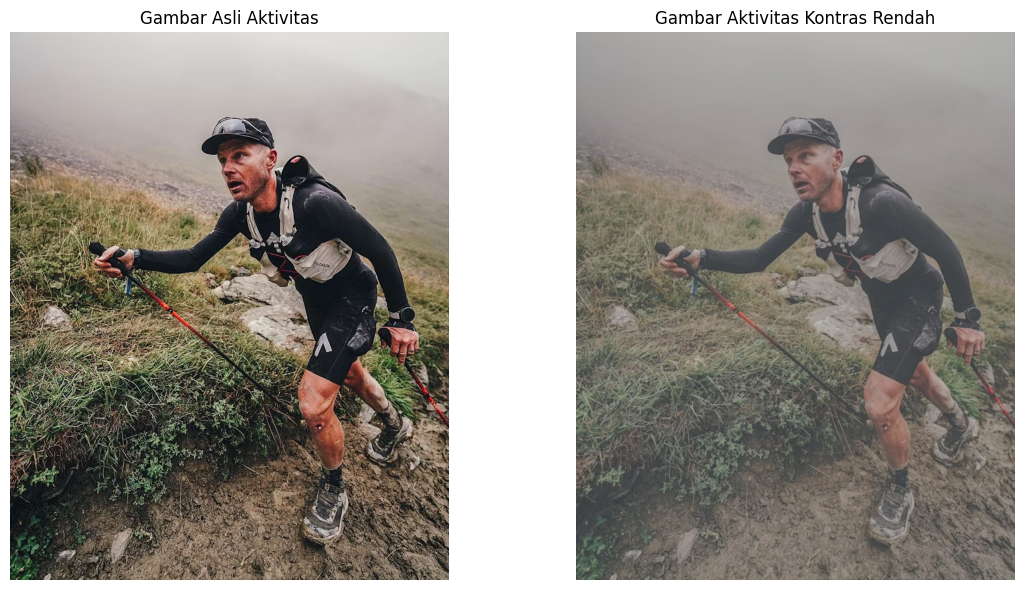

In [33]:
# Muat gambar menggunakan OpenCV
img_aktivitas = cv2.imread(file_path_aktivitas)
img_aktivitas_kontras = cv2.imread(file_path_aktivitas_kontras)

# Konversi dari BGR ke RGB karena Matplotlib menggunakan RGB
img_aktivitas_rgb = cv2.cvtColor(img_aktivitas, cv2.COLOR_BGR2RGB)
img_aktivitas_kontras_rgb = cv2.cvtColor(img_aktivitas_kontras, cv2.COLOR_BGR2RGB)

# Buat figure dan subplots
plt.figure(figsize=(12, 6)) # Sesuaikan ukuran figure sesuai kebutuhan

# Subplot pertama (kiri)
plt.subplot(1, 2, 1) # 1 baris, 2 kolom, plot pertama
plt.imshow(img_aktivitas_rgb)
plt.title('Gambar Asli Aktivitas')
plt.axis('off') # Sembunyikan sumbu

# Subplot kedua (kanan)
plt.subplot(1, 2, 2) # 1 baris, 2 kolom, plot kedua
plt.imshow(img_aktivitas_kontras_rgb)
plt.title('Gambar Aktivitas Kontras Rendah')
plt.axis('off') # Sembunyikan sumbu

plt.tight_layout() # Sesuaikan layout agar tidak tumpang tindih
plt.show()

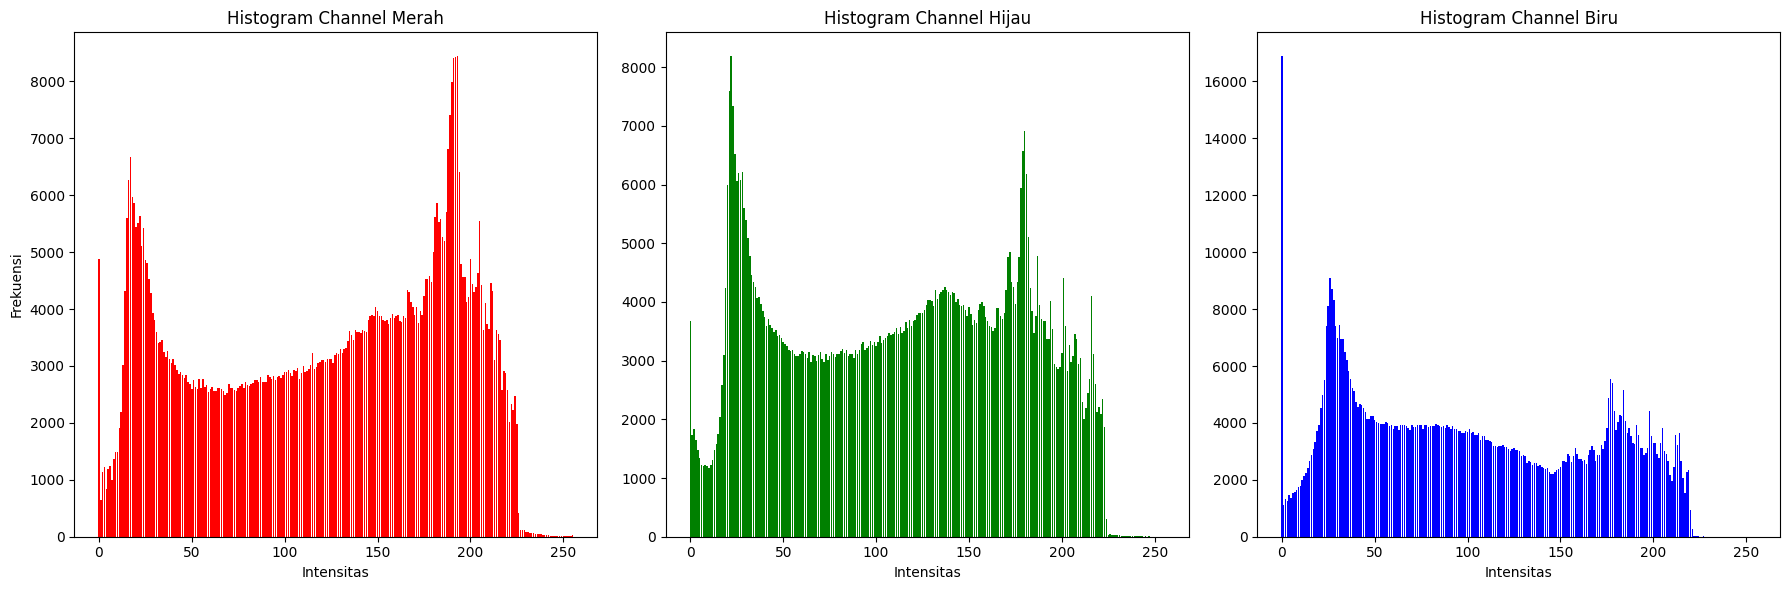

In [34]:
# Muat gambar dari file. cv2.imread memuat gambar dalam format BGR (Blue, Green, Red).
img_aktivitas = cv2.imread(file_path_aktivitas)
# Konversi format warna dari BGR ke RGB.
# Ini penting karena library seperti Matplotlib menggunakan format RGB untuk menampilkan warna yang benar.
img_aktivitas_rgb = cv2.cvtColor(img_aktivitas, cv2.COLOR_BGR2RGB)

# Ambil dimensi gambar (tinggi, lebar, jumlah channel).
height, width, _ = img_aktivitas_rgb.shape

# Siapkan 'wadah' untuk menyimpan frekuensi kemunculan setiap nilai intensitas (0-255).
# np.zeros(256) membuat sebuah array berisi 256 angka nol.
hist_r = np.zeros(256) # Untuk channel Red
hist_g = np.zeros(256) # Untuk channel Green
hist_b = np.zeros(256) # Untuk channel Blue

# Lakukan iterasi (looping) untuk mengunjungi setiap piksel pada gambar.
# Loop luar untuk baris (y), loop dalam untuk kolom (x).
for y in range(height):
    for x in range(width):
        # Ambil nilai R, G, B dari piksel di koordinat (y, x).
        r, g, b = img_aktivitas_rgb[y, x]

        # Tambahkan 1 (incremen) pada 'wadah' histogram sesuai dengan nilai intensitas piksel.
        # Contoh: jika nilai r adalah 150, maka `hist_r[150]` akan bertambah 1.
        hist_r[r] += 1
        hist_g[g] += 1
        hist_b[b] += 1

# VISUALISASI HISTOGRAM
# Buat sebuah figure untuk menampung plot dengan ukuran tertentu.
plt.figure(figsize=(18, 6))

# Plot untuk Histogram Merah
plt.subplot(1, 3, 1) # Buat subplot di posisi 1 dari grid 1x3.
plt.bar(range(256), hist_r, color='red') # Buat bar chart, sumbu x: 0-255, sumbu y: nilai frekuensi.
plt.title('Histogram Channel Merah')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')

# Plot untuk Histogram Hijau
plt.subplot(1, 3, 2) # Posisi 2 dari grid 1x3.
plt.bar(range(256), hist_g, color='green')
plt.title('Histogram Channel Hijau')
plt.xlabel('Intensitas')

# Plot untuk Histogram Biru
plt.subplot(1, 3, 3) # Posisi 3 dari grid 1x3.
plt.bar(range(256), hist_b, color='blue')
plt.title('Histogram Channel Biru')
plt.xlabel('Intensitas')

# Rapikan layout agar judul dan label tidak tumpang tindih.
plt.tight_layout()
# Tampilkan plot.
plt.show()

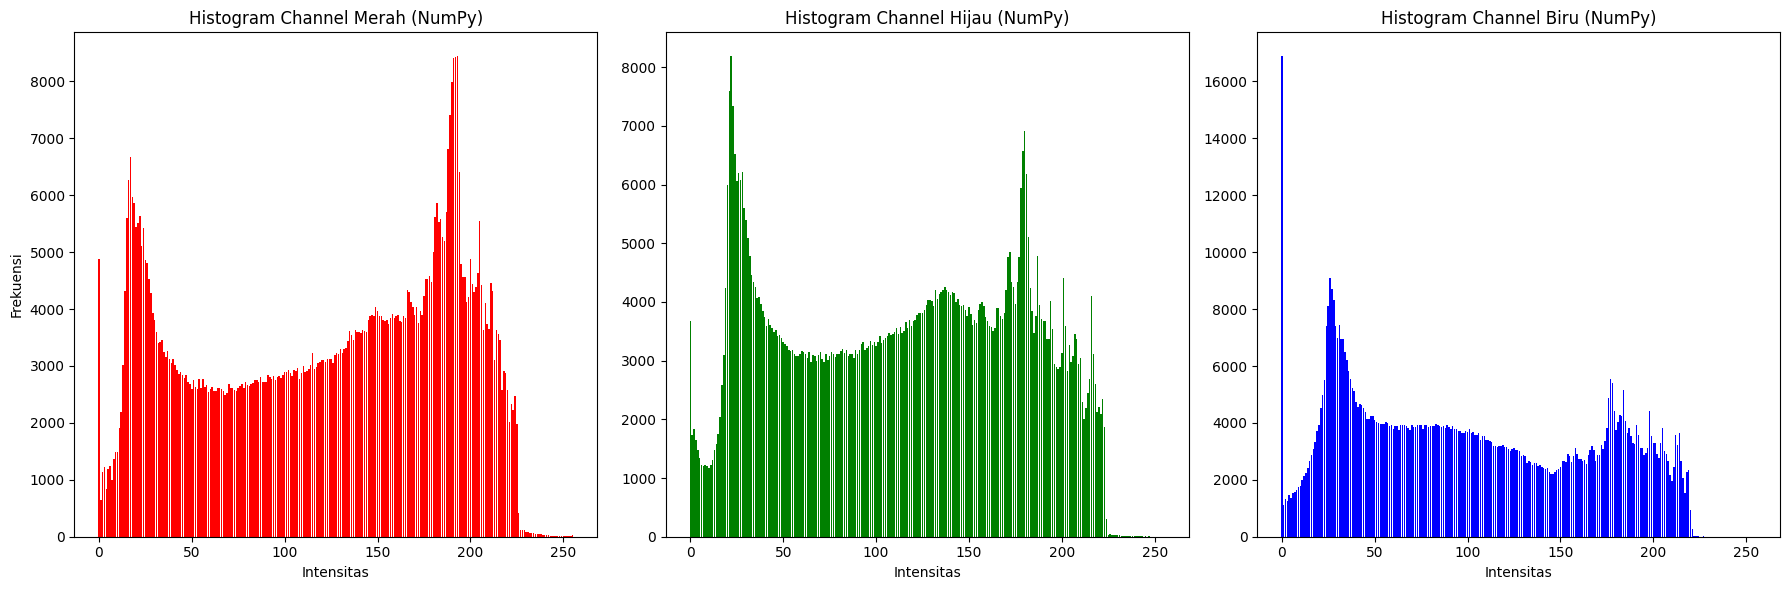

In [35]:
# Muat ulang gambar untuk memastikan proses terpisah.
img_aktivitas = cv2.imread(file_path_aktivitas)
img_aktivitas_rgb = cv2.cvtColor(img_aktivitas, cv2.COLOR_BGR2RGB)

# Hitung histogram menggunakan fungsi bawaan NumPy. Jauh lebih cepat dan efisien.
# img_aktivitas_rgb[:,:,0] -> 'slice' array untuk mengambil semua data dari channel ke-0 (Red).
# .ravel() -> 'meratakan' array 2D (matriks piksel) menjadi array 1D (satu baris panjang).
# np.histogram -> fungsi utama.
#   - Parameter 1: data piksel 1D.
#   - bins=256: jumlah 'wadah' yang akan digunakan.
#   - range=[0,256]: rentang nilai yang akan dihitung (0 sampai 255).
hist_r_np, _ = np.histogram(img_aktivitas_rgb[:,:,0].ravel(), bins=256, range=[0,256])
hist_g_np, _ = np.histogram(img_aktivitas_rgb[:,:,1].ravel(), bins=256, range=[0,256])
hist_b_np, _ = np.histogram(img_aktivitas_rgb[:,:,2].ravel(), bins=256, range=[0,256])

# VISUALISASI (langkah-langkahnya sama seperti sebelumnya)
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.bar(range(256), hist_r_np, color='red')
plt.title('Histogram Channel Merah (NumPy)')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')

plt.subplot(1, 3, 2)
plt.bar(range(256), hist_g_np, color='green')
plt.title('Histogram Channel Hijau (NumPy)')
plt.xlabel('Intensitas')

plt.subplot(1, 3, 3)
plt.bar(range(256), hist_b_np, color='blue')
plt.title('Histogram Channel Biru (NumPy)')
plt.xlabel('Intensitas')

plt.tight_layout()
plt.show()

# Hasilnya sama, tapi karena numpy histogram ini adalah fungsi official maka,
# lebih baik menggunakannya karena lebih ter-optimasi

/tmp/ipython-input-1754527095.py:47: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[0, 0].hist(r.flatten(), 256, [0, 256], color='r')
/tmp/ipython-input-1754527095.py:51: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[0, 1].hist(g.flatten(), 256, [0, 256], color='g')
/tmp/ipython-input-1754527095.py:54: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[0, 2].hist(b.flatten(), 256, [0, 256], color='b')
/tmp/ipython-input-1754527095.py:60: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 0].hist(r_e

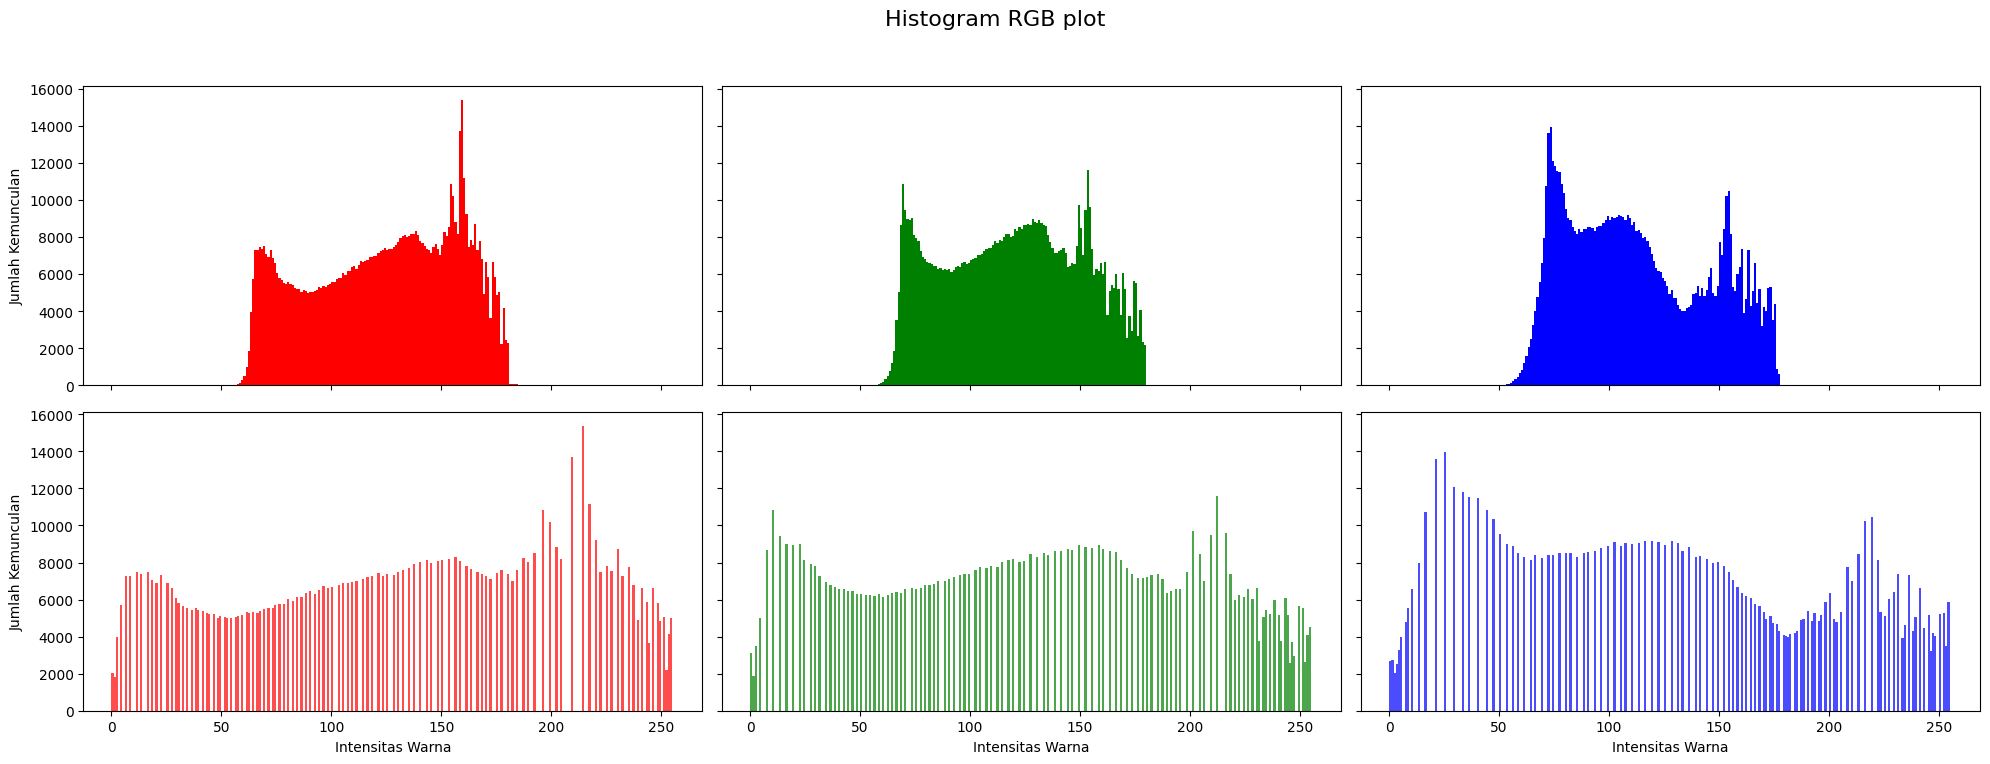

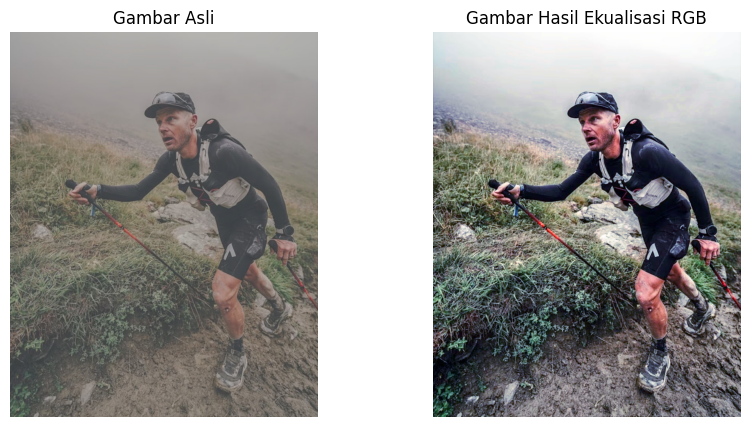

In [36]:
# PERSIAPAN DAN PROSES EKUALISASI
# ==================================
# Bagian ini tidak berubah, karena logika untuk melakukan ekualisasi
# pada setiap channel warna sudah benar.

# Muat gambar 'aktivitas_kontras.jpg'.
img_kontras = cv2.imread(file_path_aktivitas_kontras)

# Konversi ke RGB.
img_kontras_rgb = cv2.cvtColor(img_kontras, cv2.COLOR_BGR2RGB)

# Pisahkan channel R, G, B dari gambar ASLI.
r, g, b = cv2.split(img_kontras_rgb)

# Fungsi bantu untuk melakukan ekualisasi pada satu channel.
def equalize_channel(channel):
    hist, _ = np.histogram(channel.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    # Lakukan normalisasi pada CDF untuk membuat lookup table.
    cdf_normalized = np.ma.masked_equal(cdf, 0)
    cdf_normalized = (cdf_normalized - cdf_normalized.min()) * 255 / (cdf_normalized.max() - cdf_normalized.min())
    cdf_final = np.ma.filled(cdf_normalized, 0).astype('uint8')
    # Kembalikan channel yang sudah diubah nilainya berdasarkan lookup table.
    return cdf_final[channel]

# Terapkan fungsi ekualisasi pada setiap channel untuk mendapatkan channel baru.
r_equalized = equalize_channel(r)
g_equalized = equalize_channel(g)
b_equalized = equalize_channel(b)

# Gabungkan kembali channel-channel yang sudah diekualisasi.
img_equalized_rgb = cv2.merge([r_equalized, g_equalized, b_equalized])


# VISUALISASI HISTOGRAM SESUAI GAMBAR ANDA
# =========================================
# Buat figure dan set subplot dengan 2 baris dan 3 kolom.
# `sharex=True` dan `sharey=True` membuat semua plot menggunakan skala sumbu yang sama.
fig, axes = plt.subplots(2, 3, figsize=(20, 8), sharex=True, sharey=True)

# Tambahkan judul utama untuk seluruh set plot.
fig.suptitle('Histogram RGB plot', fontsize=16)

# --- BARIS PERTAMA: HISTOGRAM GAMBAR ASLI (SEBELUM EKUALISASI) ---

# Plot untuk channel R Asli
axes[0, 0].hist(r.flatten(), 256, [0, 256], color='r')
axes[0, 0].set_ylabel('Jumlah Kemunculan') # Label Y hanya untuk kolom pertama.

# Plot untuk channel G Asli
axes[0, 1].hist(g.flatten(), 256, [0, 256], color='g')

# Plot untuk channel B Asli
axes[0, 2].hist(b.flatten(), 256, [0, 256], color='b')


# --- BARIS KEDUA: HISTOGRAM GAMBAR HASIL (SESUDAH EKUALISASI) ---

# Plot untuk channel R Hasil Ekualisasi
axes[1, 0].hist(r_equalized.flatten(), 256, [0, 256], color='r', alpha=0.7) # Alpha untuk sedikit membedakan.
axes[1, 0].set_xlabel('Intensitas Warna') # Label X hanya untuk baris bawah.
axes[1, 0].set_ylabel('Jumlah Kemunculan')

# Plot untuk channel G Hasil Ekualisasi
axes[1, 1].hist(g_equalized.flatten(), 256, [0, 256], color='g', alpha=0.7)
axes[1, 1].set_xlabel('Intensitas Warna')

# Plot untuk channel B Hasil Ekualisasi
axes[1, 2].hist(b_equalized.flatten(), 256, [0, 256], color='b', alpha=0.7)
axes[1, 2].set_xlabel('Intensitas Warna')

# Rapikan layout dan tampilkan.
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # `rect` memberi ruang untuk suptitle.
plt.show()


# Tampilkan juga perbandingan gambarnya agar konteksnya lengkap.
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_kontras_rgb)
axes[0].set_title('Gambar Asli')
axes[0].axis('off')
axes[1].imshow(img_equalized_rgb)
axes[1].set_title('Gambar Hasil Ekualisasi RGB')
axes[1].axis('off')
plt.show()

/tmp/ipython-input-2359704353.py:30: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 0].hist(img_gray_s6.flatten(), 256, [0, 256], color='gray')
/tmp/ipython-input-2359704353.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 1].hist(img_equalized_s6.flatten(), 256, [0, 256], color='gray')


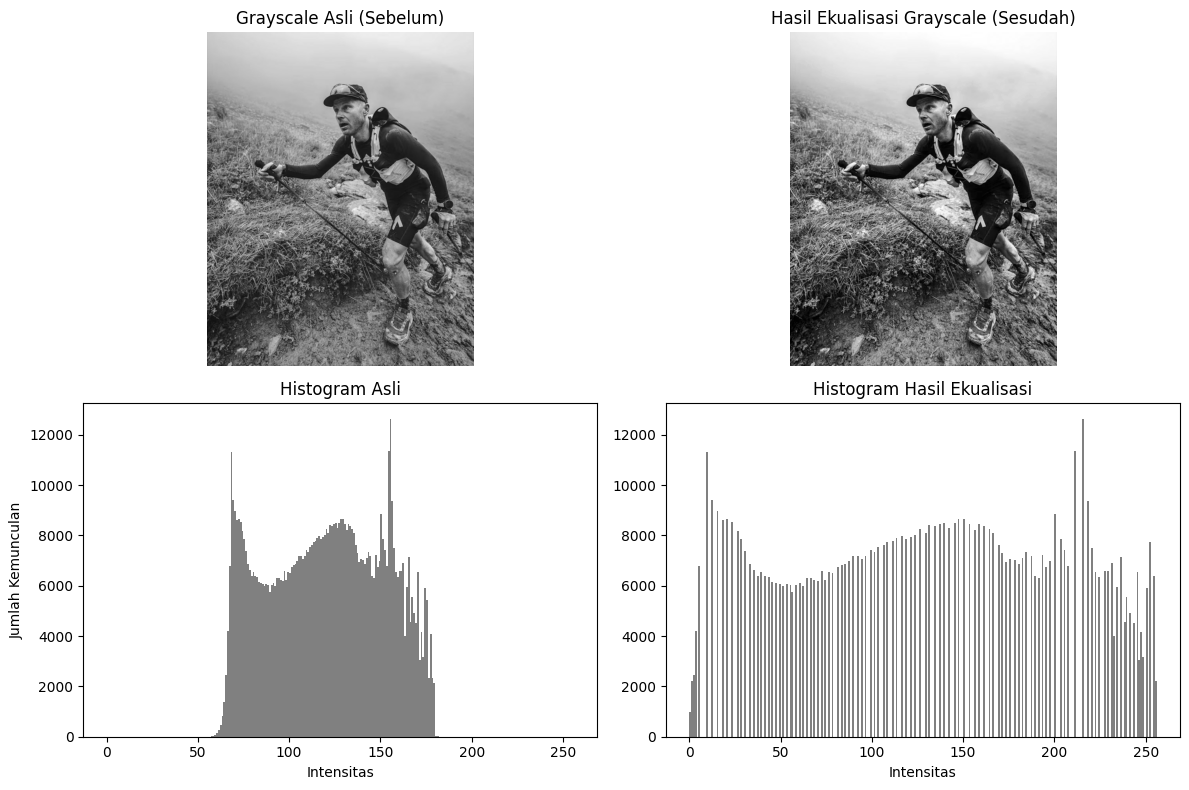

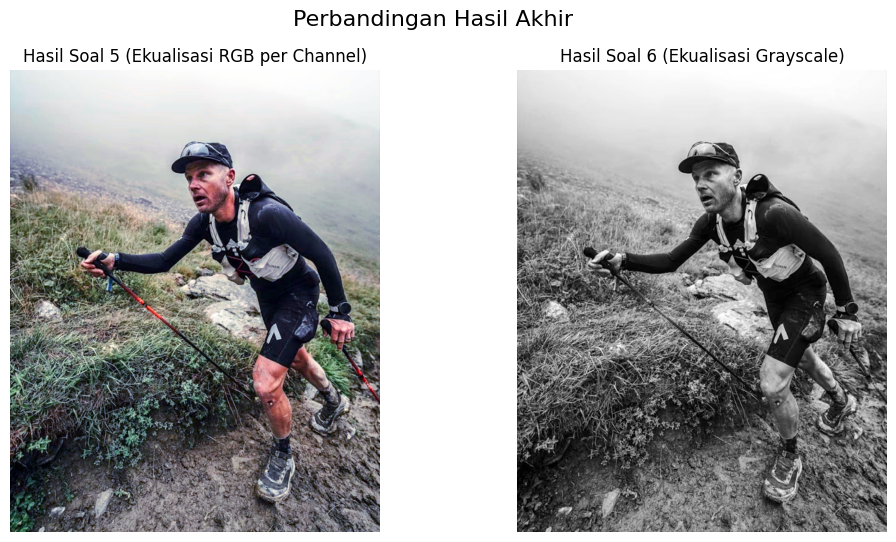

In [39]:
# SOAL 6: HISTOGRAM EQUALIZATION DENGAN LIBRARY CV2
# =================================================

# Muat gambar 'aktivitas_kontras.jpg'
img_kontras_s6 = cv2.imread(file_path_aktivitas_kontras)

# LANGKAH 1: Konversi gambar ke Grayscale.
# Ini adalah langkah wajib karena cv2.equalizeHist bekerja pada citra single-channel.
img_gray_s6 = cv2.cvtColor(img_kontras_s6, cv2.COLOR_BGR2GRAY)

# LANGKAH 2: Terapkan fungsi equalizeHist dari OpenCV.
# Cukup satu baris ini untuk melakukan seluruh proses ekualisasi pada gambar grayscale.
img_equalized_s6 = cv2.equalizeHist(img_gray_s6)

# VISUALISASI HASIL SOAL 6
# ========================
# Kita buat plot perbandingan sebelum vs sesudah untuk proses grayscale ini.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Baris pertama: Gambar Asli vs. Hasil Ekualisasi
axes[0, 0].imshow(img_gray_s6, cmap='gray')
axes[0, 0].set_title('Grayscale Asli (Sebelum)')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_equalized_s6, cmap='gray')
axes[0, 1].set_title('Hasil Ekualisasi Grayscale (Sesudah)')
axes[0, 1].axis('off')

# Baris kedua: Histogram Asli vs. Histogram Hasil Ekualisasi
axes[1, 0].hist(img_gray_s6.flatten(), 256, [0, 256], color='gray')
axes[1, 0].set_title('Histogram Asli')
axes[1, 0].set_xlabel('Intensitas')
axes[1, 0].set_ylabel('Jumlah Kemunculan')

axes[1, 1].hist(img_equalized_s6.flatten(), 256, [0, 256], color='gray')
axes[1, 1].set_title('Histogram Hasil Ekualisasi')
axes[1, 1].set_xlabel('Intensitas')

plt.tight_layout()
plt.show()

# Ambil variabel hasil dari Soal 5 (`img_equalized_rgb`) dan Soal 6 (`img_equalized_s6`)
# Pastikan kode Soal 5 sudah dijalankan sebelumnya.

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Hasil Soal 5: Ekualisasi per channel RGB (Manual)
axes[0].imshow(img_equalized_rgb)
axes[0].set_title('Hasil Soal 5 (Ekualisasi RGB per Channel)')
axes[0].axis('off')

# Hasil Soal 6: Ekualisasi Grayscale (Library CV2)
axes[1].imshow(img_equalized_s6, cmap='gray')
axes[1].set_title('Hasil Soal 6 (Ekualisasi Grayscale)')
axes[1].axis('off')

plt.suptitle('Perbandingan Hasil Akhir', fontsize=16)
plt.show()

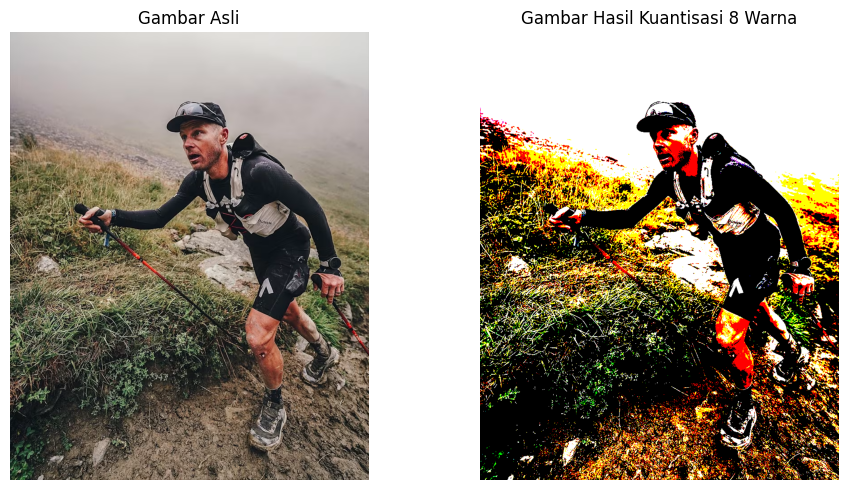

In [40]:
# Muat gambar 'aktivitas.jpg' dan konversi ke RGB.
img_aktivitas = cv2.imread(file_path_aktivitas)
img_aktivitas_rgb = cv2.cvtColor(img_aktivitas, cv2.COLOR_BGR2RGB)

# Definisikan palet 8 warna yang akan menjadi target.
# Ini adalah warna-warna yang 'diizinkan' ada di gambar hasil.
palette_rgb = np.array([
    [0, 0, 0], [255, 255, 255], [255, 0, 0], [0, 255, 0],
    [0, 0, 255], [255, 255, 0], [0, 255, 255], [255, 0, 255]
])

# Buat salinan gambar untuk dimodifikasi, agar gambar asli tidak berubah.
img_quantized = np.copy(img_aktivitas_rgb)

# Buat fungsi untuk mencari warna terdekat dalam palet.
def find_closest_color(pixel, palette):
    # Hitung 'jarak' antara warna sebuah piksel dengan SETIAP warna di palet.
    # Rumus ini adalah jarak Euclidean di ruang 3D (R, G, B).
    distances = np.sqrt(np.sum((palette - pixel)**2, axis=1))
    # Cari indeks dari jarak yang paling kecil.
    index_of_closest = np.argmin(distances)
    # Kembalikan warna dari palet pada indeks tersebut.
    return palette[index_of_closest]

# Lakukan iterasi untuk setiap piksel.
height, width, _ = img_quantized.shape
for y in range(height):
    for x in range(width):
        # Ganti warna piksel asli dengan warna terdekat dari palet.
        img_quantized[y, x] = find_closest_color(img_quantized[y, x], palette_rgb)

# VISUALISASI HASIL
# =================
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_aktivitas_rgb)
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_quantized)
plt.title('Gambar Hasil Kuantisasi 8 Warna')
plt.axis('off')

plt.tight_layout()
plt.show()

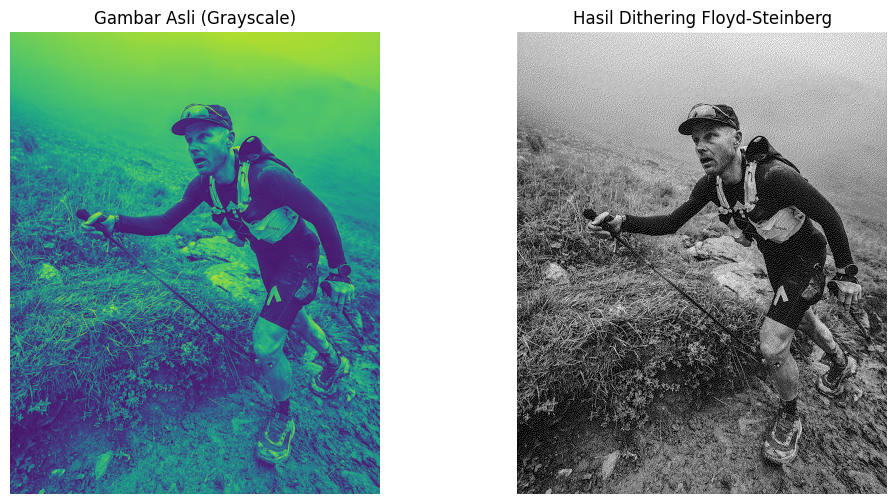

In [55]:
# SOAL 8: DithERING FLOYD-STEINBERG
# =================================

# Pertama, kita definisikan dulu fungsi untuk dithering.
# Fungsi ini akan menerima gambar grayscale dan mengembalikan gambar hasil dithering.
def floyd_steinberg_dithering(image):
    # Buat salinan gambar agar gambar asli tidak berubah.
    # Ubah tipe datanya menjadi float untuk menampung nilai desimal dari 'error'.
    img_dither = image.copy().astype(float)
    height, width = img_dither.shape

    # Lakukan iterasi untuk setiap piksel dari kiri-ke-kanan, atas-ke-bawah.
    for y in range(height - 1):
        for x in range(1, width - 1):
            # Ambil nilai piksel saat ini (piksel lama).
            old_pixel = img_dither[y, x]

            # Kuantisasi piksel: 'paksa' nilainya menjadi 0 (hitam) atau 255 (putih).
            new_pixel = round(old_pixel / 255.0) * 255
            img_dither[y, x] = new_pixel

            # Hitung 'quantization error', yaitu selisih antara nilai asli dan nilai baru.
            quant_error = old_pixel - new_pixel

            # Distribusikan error ke piksel tetangga yang belum diproses.
            img_dither[y,     x + 1] += quant_error * 7 / 16
            img_dither[y + 1, x - 1] += quant_error * 3 / 16
            img_dither[y + 1, x    ] += quant_error * 5 / 16
            img_dither[y + 1, x + 1] += quant_error * 1 / 16

    # Pastikan semua nilai piksel tetap dalam rentang 0-255.
    img_dither = np.clip(img_dither, 0, 255)
    # Konversi kembali tipe data ke integer 8-bit.
    return img_dither.astype('uint8')

# 1. Muat gambar 'aktivitas.jpg' dan konversi ke grayscale.
# file_path_aktivitas harus sudah didefinisikan di awal.
img_aktivitas_gray = cv2.cvtColor(cv2.imread(file_path_aktivitas), cv2.COLOR_BGR2GRAY)

# 2. Panggil fungsi dithering pada gambar grayscale tersebut.
dithered_aktivitas = floyd_steinberg_dithering(img_aktivitas_gray)

# --- VISUALISASI SOAL 8 ---
# Tampilkan gambar awal (grayscale) dan gambar hasil dithering secara berdampingan.
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_aktivitas_gray)
axes[0].set_title('Gambar Asli (Grayscale)')
axes[0].axis('off')

axes[1].imshow(dithered_aktivitas, cmap='gray')
axes[1].set_title('Hasil Dithering Floyd-Steinberg')
axes[1].axis('off')

plt.show()

--- HASIL SOAL 8: Dithering pada Gambar Standar ---


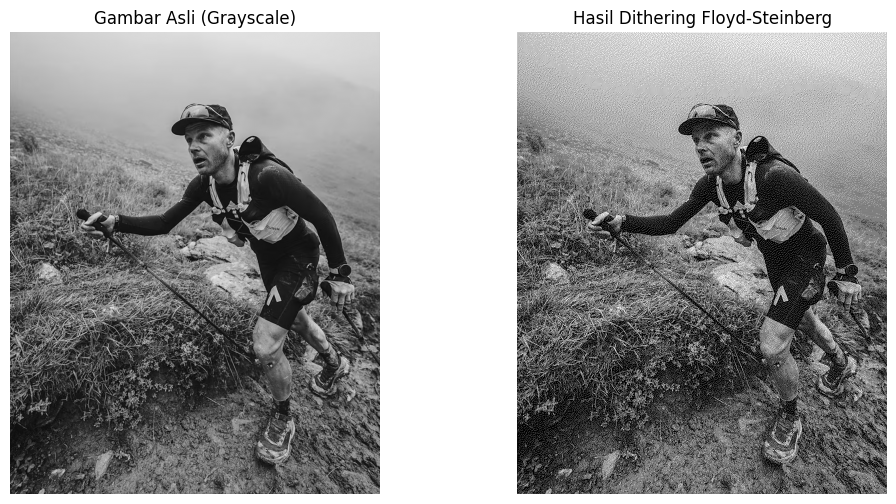

In [56]:
# 1. Muat gambar 'aktivitas.jpg' dan langsung konversi ke grayscale.
img_aktivitas_gray = cv2.cvtColor(cv2.imread(file_path_aktivitas), cv2.COLOR_BGR2GRAY)

# 2. Panggil fungsi dithering yang sudah kita buat.
dithered_aktivitas = floyd_steinberg_dithering(img_aktivitas_gray)

# --- VISUALISASI SOAL 8 ---
# Tampilkan gambar awal (grayscale) dan gambar hasil dithering secara berdampingan.
print("--- HASIL SOAL 8: Dithering pada Gambar Standar ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_aktivitas_gray, cmap='gray')
axes[0].set_title('Gambar Asli (Grayscale)')
axes[0].axis('off')

axes[1].imshow(dithered_aktivitas, cmap='gray')
axes[1].set_title('Hasil Dithering Floyd-Steinberg')
axes[1].axis('off')

plt.show()

/tmp/ipython-input-3795954905.py:44: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 0].hist(img_lc_gray_s9.flatten(), 256, [0, 256], color='gray')
/tmp/ipython-input-3795954905.py:46: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 1].hist(img_equalized_s9.flatten(), 256, [0, 256], color='gray')


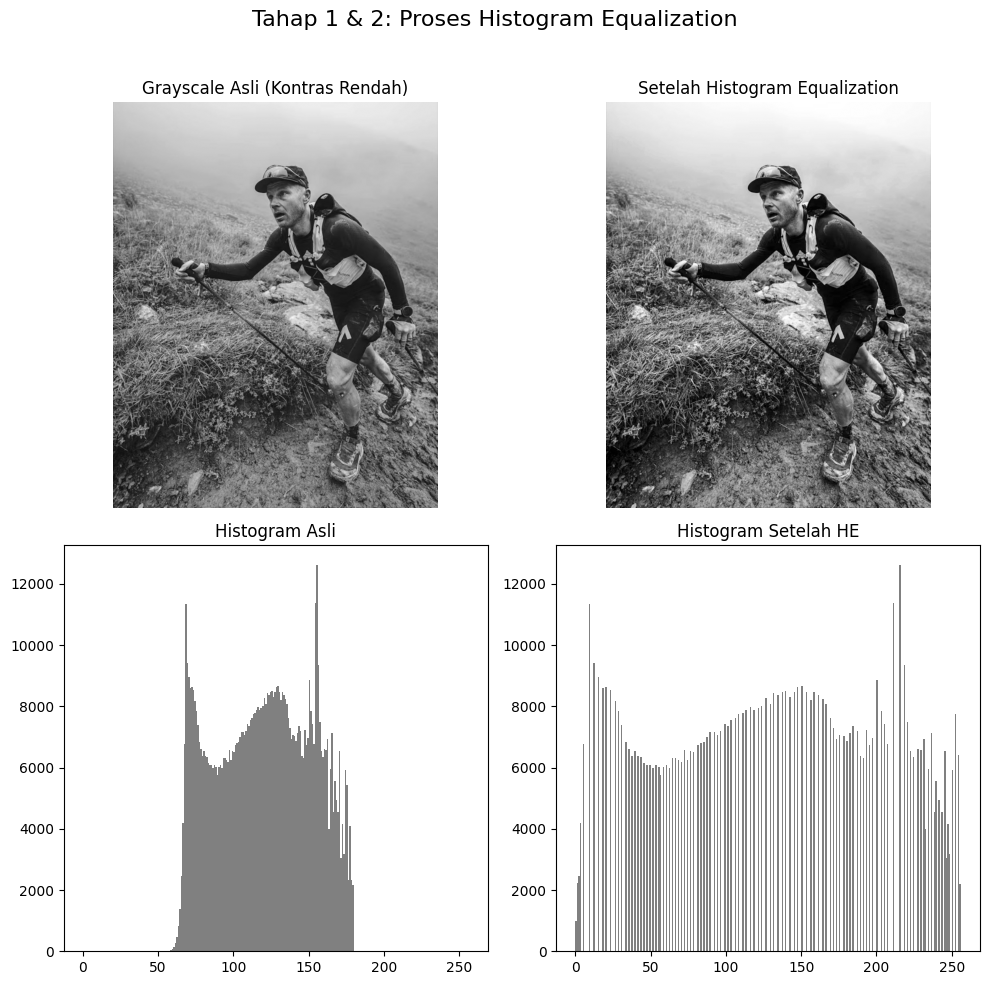

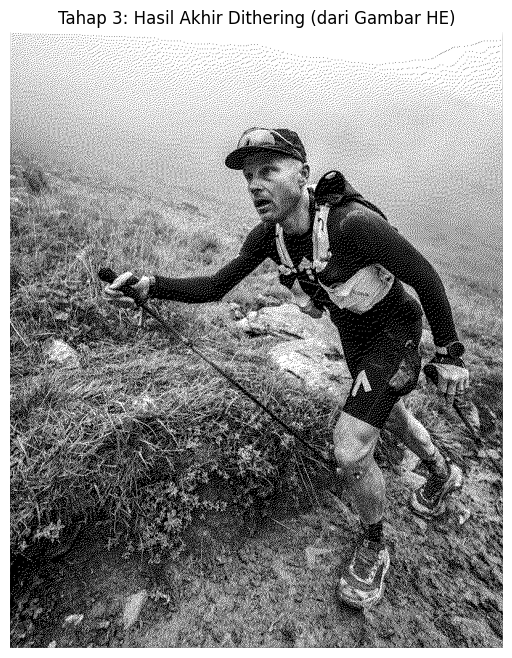

In [59]:
# Kita gunakan lagi fungsi dithering yang sama dari Soal 8.
def floyd_steinberg_dithering(image):
    img_dither = image.copy().astype(float)
    height, width = img_dither.shape
    for y in range(height - 1):
        for x in range(1, width - 1):
            old_pixel = img_dither[y, x]
            new_pixel = round(old_pixel / 255.0) * 255
            img_dither[y, x] = new_pixel
            quant_error = old_pixel - new_pixel
            img_dither[y,     x + 1] += quant_error * 7 / 16
            img_dither[y + 1, x - 1] += quant_error * 3 / 16
            img_dither[y + 1, x    ] += quant_error * 5 / 16
            img_dither[y + 1, x + 1] += quant_error * 1 / 16
    img_dither = np.clip(img_dither, 0, 255)
    return img_dither.astype('uint8')

# LANGKAH 1: Muat gambar 'aktivitas_kontras.jpg' dan konversi ke grayscale.
# file_path_aktivitas_kontras harus sudah didefinisikan di awal.
img_lc_gray_s9 = cv2.cvtColor(cv2.imread(file_path_aktivitas_kontras), cv2.COLOR_BGR2GRAY)

# LANGKAH 2: Perbaiki kontras gambar dengan histogram equalization.
img_equalized_s9 = cv2.equalizeHist(img_lc_gray_s9)

# LANGKAH 3: Terapkan dithering pada gambar yang SUDAH diekualisasi.
dithered_final_s9 = floyd_steinberg_dithering(img_equalized_s9)

# --- VISUALISASI SOAL 9 ---
# Tampilkan semua tahapan proses agar perubahannya terlihat jelas.

# Plot pertama: menampilkan perubahan gambar dan histogramnya.
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Tahap 1 & 2: Proses Histogram Equalization', fontsize=16)

# Gambar Grayscale Asli vs. Hasil HE
axes[0, 0].imshow(img_lc_gray_s9, cmap='gray')
axes[0, 0].set_title('Grayscale Asli (Kontras Rendah)')
axes[0, 0].axis('off')
axes[0, 1].imshow(img_equalized_s9, cmap='gray')
axes[0, 1].set_title('Setelah Histogram Equalization')
axes[0, 1].axis('off')

# Histogram Asli vs. Histogram Hasil HE
axes[1, 0].hist(img_lc_gray_s9.flatten(), 256, [0, 256], color='gray')
axes[1, 0].set_title('Histogram Asli')
axes[1, 1].hist(img_equalized_s9.flatten(), 256, [0, 256], color='gray')
axes[1, 1].set_title('Histogram Setelah HE')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Plot kedua: menampilkan hasil akhir proses dithering.
plt.figure(figsize=(8, 8))
plt.imshow(dithered_final_s9, cmap='gray')
plt.title('Tahap 3: Hasil Akhir Dithering (dari Gambar HE)')
plt.axis('off')
plt.show()